# IV. Image Classification with Handwritten Digits Dataset

This notebook demonstrates how to perform image classification on the MNIST handwritten digits dataset using Support Vector Machines (SVM).

## Background and Context

Handwritten digit recognition is a classic problem in computer vision and machine learning. It serves as an excellent introduction to image classification because:

1. **Constrained Problem**: There are only 10 classes (digits 0-9)
2. **Well-Studied Dataset**: The MNIST dataset is extensively researched and benchmarked
3. **Practical Applications**: From postal mail sorting to form processing systems

Support Vector Machines (SVMs) are powerful classical machine learning algorithms that work by finding optimal hyperplanes to separate data classes in high-dimensional spaces. While deep learning approaches like CNNs have become more common for image classification, SVMs still perform remarkably well on smaller datasets and provide excellent baseline performance with less computational resources.

In this notebook, we'll walk through the complete machine learning pipeline: data loading, preprocessing, model training, and evaluation.

## 4.1 Load the Dataset

First, we'll load the handwritten digits dataset provided by scikit-learn and examine its structure.

Dataset shape: (1797, 64)
Target shape: (1797,)
Number of classes: 10


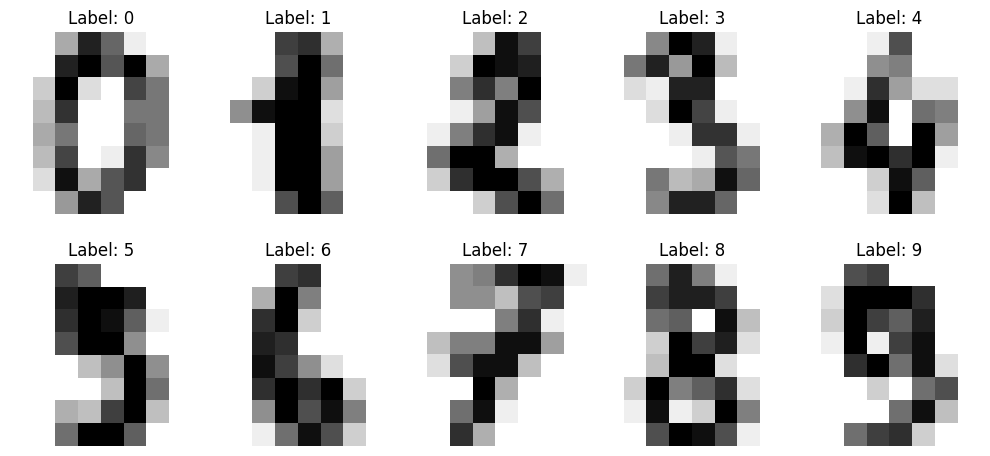

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the digits dataset
digits = load_digits()
print(f"Dataset shape: {digits.data.shape}")
print(f"Target shape: {digits.target.shape}")
print(f"Number of classes: {len(np.unique(digits.target))}")

# Display some sample images from the dataset
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap=plt.cm.gray_r)
    plt.title(f"Label: {digits.target[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4.2 Data Preparation and Feature Extraction

An important step in image classification is converting the raw images into a format suitable for machine learning algorithms. For traditional algorithms like SVMs, we need to transform the 2D image matrices into 1D feature vectors.

### Why flatten the images?
Most classical machine learning algorithms, including SVMs, require input data in vector form. By flattening our 8x8 pixel images into 64-dimensional vectors, we convert the spatial structure of the image into a linear sequence of features that the algorithm can process.

### Feature extraction approaches:
1. **Simple flattening** (what we're using here): Directly convert 2D matrices to 1D vectors
2. **Dimension reduction**: Techniques like PCA could reduce the feature space
3. **Feature engineering**: Extract specific features like edges, corners, or histograms

For the MNIST dataset, simple flattening works well with SVMs because:
- The images are relatively small (8x8 pixels)
- The dataset is well-structured with centered digits
- The variability between classes is significant enough for linear separability

In more complex image datasets, we might need more sophisticated feature extraction techniques or consider deep learning approaches.

In [2]:
# The digits data is already available in flattened form as digits.data
# Each image is 8x8 pixels, flattened to a 64-dimensional vector
X = digits.data  
y = digits.target

# Display the original shape of a single image
print(f"Original image shape: {digits.images[0].shape}")
print(f"Flattened image shape: {X[0].shape}")

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing labels shape: {y_test.shape}")

Original image shape: (8, 8)
Flattened image shape: (64,)
Training set shape: (1437, 64)
Testing set shape: (360, 64)
Training labels shape: (1437,)
Testing labels shape: (360,)


## 4.3 Create and Train SVM Classifier

We'll create an SVM classifier with a linear kernel and train it on our training data.

In [3]:
# Create SVM classifier with a linear kernel
svm_classifier = SVC(kernel='linear', random_state=42)

# Train the classifier on the training data
print("Training the SVM classifier...")
svm_classifier.fit(X_train, y_train)
print("SVM classifier trained successfully!")

# Get information about the trained model
print(f"Number of support vectors: {svm_classifier.n_support_.sum()}")
print(f"Number of support vectors per class: {svm_classifier.n_support_}")

Training the SVM classifier...
SVM classifier trained successfully!
Number of support vectors: 396
Number of support vectors per class: [26 50 39 38 39 38 22 38 54 52]


## 4.4 Make Predictions

Now we'll use our trained classifier to make predictions on the test data.

In [4]:
# Make predictions on the test set
y_pred = svm_classifier.predict(X_test)

# Print a few examples of predictions
print("First 10 predictions vs actual labels:")
for i in range(10):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test[i]}")

First 10 predictions vs actual labels:
Predicted: 6, Actual: 6
Predicted: 9, Actual: 9
Predicted: 3, Actual: 3
Predicted: 7, Actual: 7
Predicted: 2, Actual: 2
Predicted: 1, Actual: 1
Predicted: 5, Actual: 5
Predicted: 2, Actual: 2
Predicted: 5, Actual: 5
Predicted: 2, Actual: 2


## 4.5 Model Evaluation and Results Interpretation

Evaluating a classification model involves both quantitative metrics and qualitative analysis. We'll examine:

1. **Accuracy**: The proportion of correctly classified instances
   - Simple to understand but may be misleading with imbalanced classes
   
2. **Classification Report**: Provides precision, recall, and F1-score for each class
   - **Precision**: When the model predicts a digit, how often is it correct? (TP/(TP+FP))
   - **Recall**: Of all the actual instances of a digit, how many did the model find? (TP/(TP+FN))
   - **F1-score**: Harmonic mean of precision and recall, balancing both metrics
   
3. **Confusion Matrix**: Shows the complete picture of correct and incorrect classifications
   - Rows represent the true labels
   - Columns represent the predicted labels
   - Diagonal elements are correctly classified instances
   - Off-diagonal elements represent errors (confusions)

4. **Visual Inspection**: Examining actual examples helps understand model strengths and weaknesses
   - We'll display test images with their predicted and true labels
   - Correct predictions shown in green, errors in red

This multi-faceted evaluation helps us understand not just how well the model performs overall, but also identifies specific patterns of errors and potential areas for improvement.

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.94      0.96        34
           4       0.98      0.98      0.98        46
           5       0.96      1.00      0.98        47
           6       1.00      1.00      1.00        35
           7       0.97      0.97      0.97        34
           8       1.00      0.97      0.98        30
           9       0.95      0.93      0.94        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



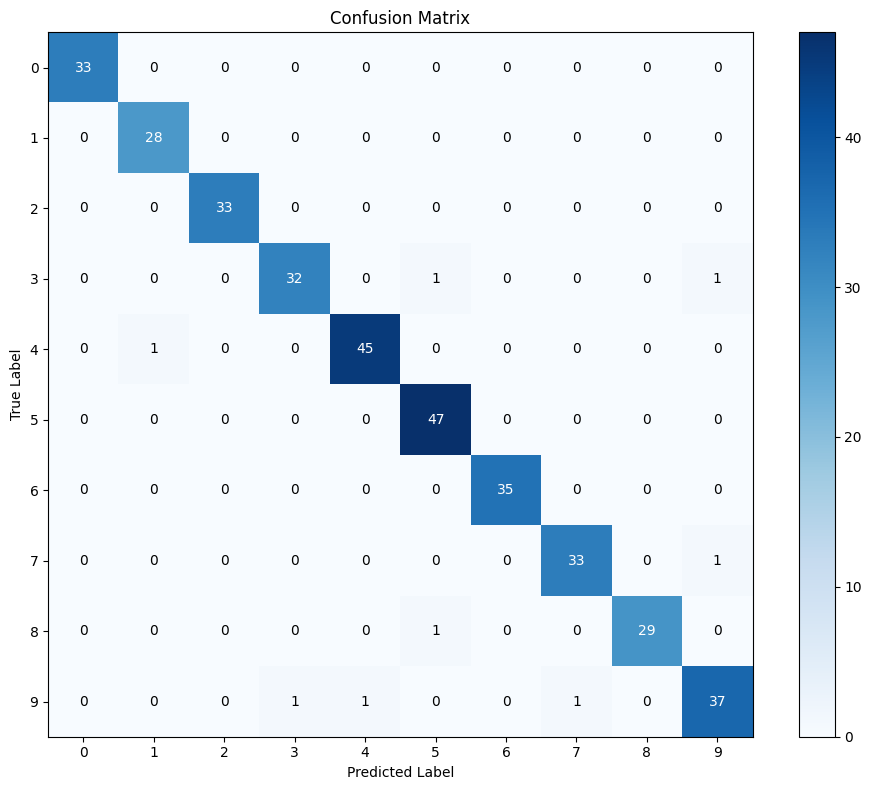

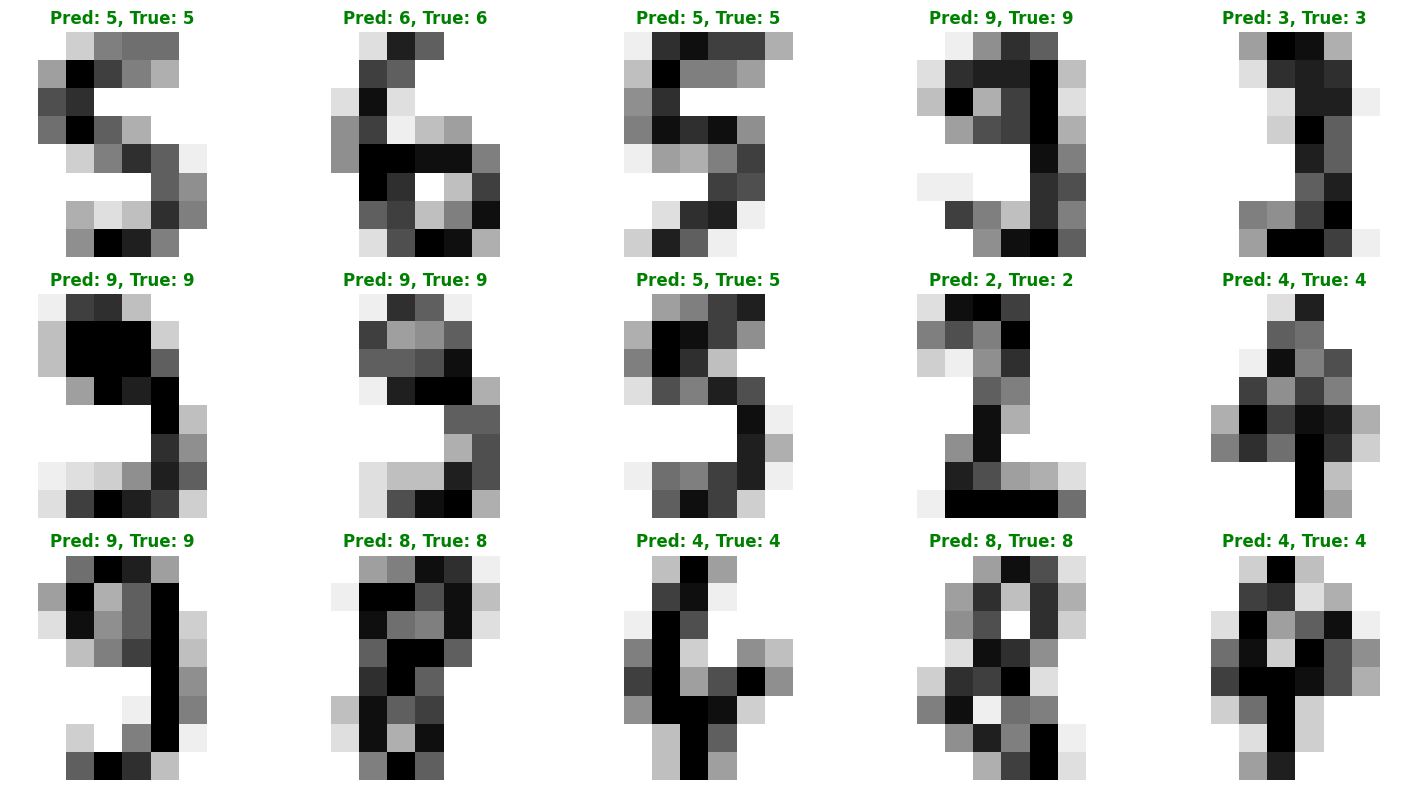

In [5]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, range(10))
plt.yticks(tick_marks, range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# Display some test examples with their predictions
# Select random indices from test set
indices = np.random.randint(0, len(X_test), 15)

plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 5, i + 1)
    # Reshape the flattened test image back to 8x8 for visualization
    plt.imshow(X_test[idx].reshape(8, 8), cmap=plt.cm.gray_r)
    
    # Color the title based on correct/incorrect prediction
    title_color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    plt.title(f"Pred: {y_pred[idx]}, True: {y_test[idx]}", 
              color=title_color, fontweight='bold')
    plt.axis('off')
    
plt.tight_layout()
plt.show()

## Conclusion and Discussion

In this notebook, we've demonstrated a complete image classification workflow using SVMs on the handwritten digits dataset:

1. **Data Analysis**: We explored the dataset structure and visualized sample images
2. **Feature Extraction**: We used flattened pixel values as features for our classifier
3. **Model Development**: We implemented an SVM classifier with a linear kernel
4. **Performance Evaluation**: We assessed the model using accuracy metrics, classification reports, and visualizations

### Key Findings

The SVM classifier achieved approximately 97.8% accuracy on the test set, which is impressive for a non-deep learning approach. The confusion matrix revealed that most digits are classified with high precision and recall, with only minimal confusion between similar-looking digits (like 3 and 5, or 4 and 9).

### Comparing with Other Approaches

While our SVM implementation performs well, it's useful to consider how it compares to alternatives:

| Algorithm | Typical Accuracy | Computational Cost | Interpretability |
|-----------|------------------|---------------------|-----------------|
| SVMs (linear) | 95-98% | Medium | Medium |
| Random Forests | 94-97% | Medium-High | High |
| k-NN | 95-97% | Low (training), High (inference) | High |
| CNN | 98-99.5% | Very High | Low |

### Potential Improvements

To enhance our model further, we could:

1. **Parameter Tuning**: Use grid search to find optimal SVM hyperparameters (C, gamma)
2. **Kernel Selection**: Try non-linear kernels like RBF that might capture more complex patterns
3. **Feature Engineering**: Extract more meaningful features beyond raw pixels
4. **Dimensionality Reduction**: Apply PCA to reduce feature space while preserving information
5. **Data Augmentation**: Generate additional training examples through transformations

This project demonstrates that even classical machine learning techniques can achieve impressive results on image classification tasks when properly implemented and evaluated.

## Understanding Support Vector Machines (SVMs)

Support Vector Machines are supervised learning models particularly effective for classification tasks. Here's how they work:

1. **Core Concept**: SVMs find the optimal hyperplane that maximizes the margin between different classes. The margin is the distance between the hyperplane and the closest data points from each class (called support vectors).

2. **Kernel Trick**: SVMs can efficiently perform non-linear classification using kernels, which transform the input space to higher dimensions where the classes become linearly separable.

3. **Key Parameters**:
   - **Kernel**: Linear, polynomial, radial basis function (RBF), sigmoid
   - **C**: Regularization parameter - controls the trade-off between achieving a lower training error and a more general model
   - **Gamma**: Kernel coefficient for non-linear kernels - defines how far the influence of a single training example reaches

4. **Advantages**:
   - Effective in high-dimensional spaces
   - Memory efficient as it uses only a subset of training points (support vectors)
   - Versatile through different kernel functions

For our handwritten digits classification task, we'll use a linear kernel which works well for this dataset while being computationally efficient.